# B_S3.1 — Permutation Test Results Visualization

Analyzes the output of B_S3 (permutation test) to evaluate the testing framework.

**Detection rule**: For each case, p = #{T_perm ≥ T_obs} / B. If p ≤ α → reject H0 → detectable.

| Section | Question |
|---------|----------|
| 1. Classification overview | Overall detection rates by category |
| 2. p-value uniformity | True Null p-values should be Uniform(0,1) |
| 3. FPR calibration | Is false positive rate ≤ α under True Null? |
| 4. Null distribution examples | Shape of null vs observed for selected cases |
| 5. Detection by SNR | How does signal strength affect detection? |
| 6. Detection by function family | Which functions are hard to detect? |
| 7. Metric contribution | Which metrics drive the joint test? |
| 8. Variance-only detection | Can the framework detect spread-only dependence? |
| 9. Metric ablation | How much does each metric group contribute? |

In [1]:
from __future__ import annotations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import seaborn as sns
%matplotlib inline

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

S1_DIR = Path('output/S1')
S3_DIR = Path('output/S3')
VIZ_DIR = Path('output/S3/viz')
VIZ_DIR.mkdir(parents=True, exist_ok=True)

# Load case metadata
cases_main = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
cases_null = pd.read_csv(S1_DIR / 'null_expanded_cases.csv', low_memory=False)
cases_main['source'] = 'main'
cases_null['source'] = 'null_expanded'
offset = cases_main['case_id'].max()
cases_null['case_id'] = cases_null['case_id'] + offset
cases_df = pd.concat([cases_main, cases_null], ignore_index=True)

is_null = cases_df['family_id'] == 'Null'
is_const = cases_df['spread_pattern'] == 'constant'
cases_df['category'] = 'mean+variance'
cases_df.loc[is_null & is_const, 'category'] = 'true_null'
cases_df.loc[~is_null & is_const, 'category'] = 'mean_only'
cases_df.loc[is_null & ~is_const, 'category'] = 'variance_only'

# Load permutation results
perm_path = S3_DIR / 'permutation_all.parquet'
if perm_path.exists():
    perm = pd.read_parquet(perm_path)
    df = cases_df.merge(perm, on='case_id', suffixes=('', '_p'))
    HAS_PERM_RESULTS = True
    print(f'Loaded {len(df):,} cases with permutation results')
else:
    df = cases_df.copy()
    HAS_PERM_RESULTS = False
    print(f'Permutation result not found: {perm_path}')
    print('Only the permuted-scatterplot illustration can run.')

if HAS_PERM_RESULTS:
    Z_COLS = sorted([c for c in df.columns if c.startswith('z_')])
    df['detected'] = df['classification'] == 'detectable'
    print(f'Z-score metrics: {len(Z_COLS)}')
    print(f'Detected (p ≤ 0.05): {df["detected"].sum():,} / {len(df):,} ({df["detected"].mean():.1%})')

print(f'\n{df["category"].value_counts()}')

Loaded 15,008 cases with permutation results
Z-score metrics: 45
Detected (p ≤ 0.05): 10,877 / 15,008 (72.5%)

category
true_null        4032
mean_only        4000
mean+variance    4000
variance_only    2976
Name: count, dtype: int64


In [2]:
CAT_ORDER = ['true_null', 'variance_only', 'mean_only', 'mean+variance']
CAT_COLORS = {'true_null': '#999999', 'variance_only': '#f59e0b',
              'mean_only': '#3b82f6', 'mean+variance': '#10b981'}
CAT_LABELS = {'true_null': 'True Null', 'variance_only': 'Variance-only',
              'mean_only': 'Mean-only', 'mean+variance': 'Mean+Variance'}

ALPHA = 0.05

## 0. Permuted Scatterplot Illustration

This section does not require `output/S3/permutation_all.parquet`. It only illustrates the permutation idea visually: keep the same `x` values and the same set of `y` values, then randomly reassign `y` to `x`. This breaks the pairing while preserving both marginal distributions.


In [3]:
import json
# Load raw scatter points for visualizing y-permutation only.
pts_main = np.load(S1_DIR / 'scatter_points.npz')
pts_null = np.load(S1_DIR / 'null_expanded_points.npz')
x_points = np.concatenate([pts_main['x'], pts_null['x']], axis=0)
y_points = np.concatenate([pts_main['y'], pts_null['y']], axis=0)
case_to_point_idx = pd.Series(np.arange(len(cases_df)), index=cases_df['case_id']).to_dict()


def _choose_case(mask, preferred=None):
    sub = cases_df[mask].copy()
    if len(sub) == 0:
        return None
    if preferred is not None:
        for col, val in preferred.items():
            if col in sub.columns:
                cand = sub[sub[col].astype(str) == str(val)]
                if len(cand) > 0:
                    sub = cand
    return sub.iloc[0]


def select_scatter_permutation_examples():
    examples = []

    # 1. True Null: f(x)=constant and spread is constant.
    row = _choose_case(
        (cases_df['family_id'] == 'Null') & (cases_df['spread_pattern'] == 'constant'),
        preferred={'x_distribution': 'even'}
    )
    if row is not None:
        examples.append(('True Null\nconstant mean + constant spread', row))

    # 2. Variance-only: f(x)=constant but spread varies with x.
    row = _choose_case(
        (cases_df['family_id'] == 'Null') & (cases_df['spread_pattern'] != 'constant'),
        preferred={'spread_pattern': 'middle_high', 'x_distribution': 'even'}
    )
    if row is not None:
        examples.append(('Variance-only\nconstant mean + varying spread', row))

    # 3. Mean-only: f(x) varies but spread is constant.
    row = _choose_case(
        (cases_df['family_id'] == 'F07') & (cases_df['spread_pattern'] == 'constant'),
        preferred={'variant_name': 'k_8', 'snr': '2.0', 'x_distribution': 'even'}
    )
    if row is None:
        row = _choose_case((cases_df['family_id'] != 'Null') & (cases_df['spread_pattern'] == 'constant'))
    if row is not None:
        examples.append(('Mean-only saturation\nvarying mean + constant spread', row))

    # 4. Mean + variance: f(x) varies and spread also varies with x.
    row = _choose_case(
        (cases_df['family_id'] == 'F07') & (cases_df['spread_pattern'] == 'middle_high'),
        preferred={'variant_name': 'k_8', 'snr': '2.0', 'x_distribution': 'even'}
    )
    if row is None:
        row = _choose_case((cases_df['family_id'] != 'Null') & (cases_df['spread_pattern'] != 'constant'))
    if row is not None:
        examples.append(('Mean + variance saturation\nvarying mean + varying spread', row))

    return examples




def _triangular_local(x, center, width):
    return np.maximum(0.0, 1.0 - np.abs(x - center) / width)


def true_function_from_row(x, row):
    """Evaluate the original synthetic mean function f(x) for a case row."""
    x = np.asarray(x, dtype=float)
    fid = str(row['family_id'])
    if fid == 'Null':
        return np.zeros_like(x, dtype=float)

    p = json.loads(row['params_json']) if isinstance(row.get('params_json', None), str) else {}

    negative = {'F04': 'F03', 'F06': 'F05', 'F08': 'F07', 'F10': 'F09',
                'F12': 'F11', 'F14': 'F13', 'F16': 'F15'}
    if fid in negative:
        row2 = row.copy()
        row2['family_id'] = negative[fid]
        return -true_function_from_row(x, row2)

    if fid in {'F01', 'F02'}:
        return p['slope'] * x + p.get('intercept', 0.0)
    if fid in {'F03', 'F05'}:
        return x ** p['p']
    if fid == 'F07':
        return 1.0 - np.exp(-p['k'] * x)
    if fid == 'F09':
        return np.log1p(p['a'] * x)
    if fid == 'F11':
        return p['base'] ** (x * p['x_range'])
    if fid == 'F13':
        return p['L1'] + (p['L2'] - p['L1']) / (1.0 + np.exp(-p['k'] * (x - p['c'])))
    if fid == 'F15':
        t = np.clip((x - (p['c'] - p['delta'])) / (2.0 * p['delta']), 0.0, 1.0)
        return p['a'] + (p['b'] - p['a']) * t
    if fid == 'F17':
        return -p['a'] * (x - p['c']) ** 2 + p['d']
    if fid == 'F18':
        return p['a'] * (x - p['c']) ** 2 + p['d']
    if fid == 'F19':
        return _triangular_local(x, p['c'], p['width'])
    if fid == 'F20':
        return 1.0 - _triangular_local(x, p['c'], p['width'])
    if fid == 'F21':
        r1, r2, r3 = p['roots']
        return p['a'] * (x - r1) * (x - r2) * (x - r3) + p['d']
    if fid == 'F22':
        name = str(row['variant_name'])
        if name.startswith('double_gaussian'):
            return (p['A1'] * np.exp(-((x - p['mu1']) ** 2) / p['sigma1'] ** 2)
                  + p['A2'] * np.exp(-((x - p['mu2']) ** 2) / p['sigma2'] ** 2))
        if name.startswith('pure_osc'):
            return p['A'] * np.sin(p['omega'] * x)
        if name.startswith('oscillation_trend'):
            return p['b'] * x + p['A'] * np.sin(p['omega'] * x)
        if name == 'damped_oscillation':
            return p['A'] * np.exp(-p['lambda'] * x) * np.sin(p['omega'] * x)
        if name == 'growing_oscillation':
            return p['A'] * np.exp(p['lambda'] * x) * np.sin(p['omega'] * x)
        if name == 'varying_frequency':
            return p['A'] * np.sin(p['omega'] * x * (1.0 + x))

    return np.full_like(x, np.nan, dtype=float)


scatter_perm_examples = select_scatter_permutation_examples()
print(f'Selected {len(scatter_perm_examples)} cases for scatterplot permutation illustration:')
for title, row in scatter_perm_examples:
    snr = row['snr'] if 'snr' in row.index else 'NA'
    print(f'  case_id={int(row.case_id):>6} | {title.replace(chr(10), " ")} | family={row.family_id} | SNR={snr} | spread={row.spread_pattern} | x={row.x_distribution}')





Selected 4 cases for scatterplot permutation illustration:
  case_id= 91009 | True Null constant mean + constant spread | family=Null | SNR=inf | spread=constant | x=even
  case_id= 91033 | Variance-only constant mean + varying spread | family=Null | SNR=inf | spread=middle_high | x=even
  case_id= 14721 | Mean-only saturation varying mean + constant spread | family=F07 | SNR=2.0 | spread=constant | x=even
  case_id= 14745 | Mean + variance saturation varying mean + varying spread | family=F07 | SNR=2.0 | spread=middle_high | x=even


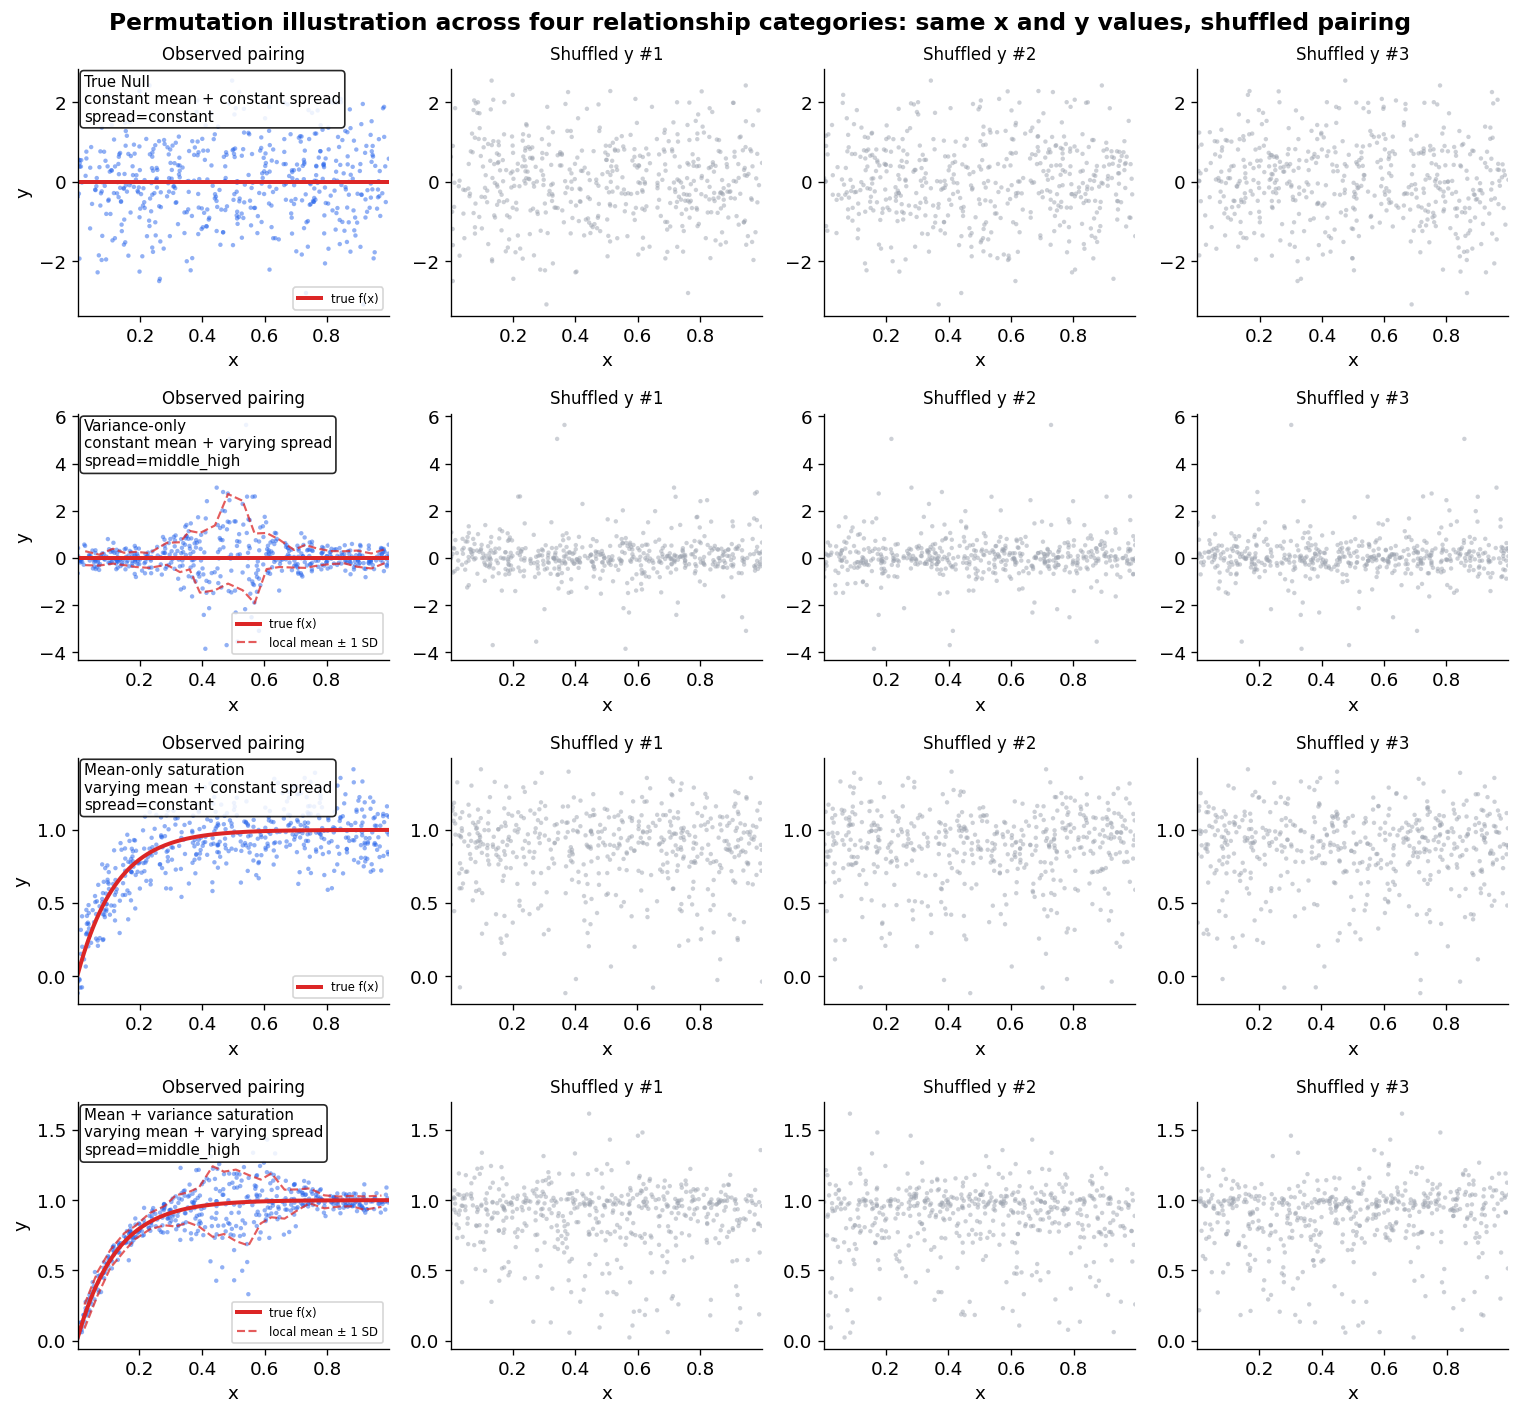

In [4]:
N_SHUFFLED_PANELS = 3
PERMUTED_SCATTER_SEED = 202406


def binned_mean_and_sd(x, y, n_bins=24, min_count=6):
    order = np.argsort(x)
    xs = np.asarray(x)[order]
    ys = np.asarray(y)[order]
    bins = np.array_split(np.arange(len(xs)), n_bins)
    xb, ymean, ysd = [], [], []
    for idx in bins:
        if len(idx) < min_count:
            continue
        xb.append(float(np.mean(xs[idx])))
        ymean.append(float(np.mean(ys[idx])))
        ysd.append(float(np.std(ys[idx], ddof=1)))
    return np.array(xb), np.array(ymean), np.array(ysd)


def draw_observed_relationship_overlay(ax, x, y, row):
    # Solid red line: the original synthetic generating function f(x).
    x_grid = np.linspace(float(np.nanmin(x)), float(np.nanmax(x)), 300)
    y_true = true_function_from_row(x_grid, row)
    if np.isfinite(y_true).any():
        ax.plot(x_grid, y_true, color='#dc2626', lw=2.4, label='true f(x)')

    # Dashed red lines: local mean ± 1 SD, shown only when spread varies with x.
    xb, ym, ys = binned_mean_and_sd(x, y)
    if row['spread_pattern'] != 'constant' and len(xb) > 0:
        ax.plot(xb, ym + ys, color='#dc2626', lw=1.3, ls='--', alpha=0.75, label='local mean ± 1 SD')
        ax.plot(xb, ym - ys, color='#dc2626', lw=1.3, ls='--', alpha=0.75)

    ax.legend(fontsize=7, loc='lower right')


if len(scatter_perm_examples) > 0:
    n_rows = len(scatter_perm_examples)
    n_cols = 1 + N_SHUFFLED_PANELS
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3 * n_rows), squeeze=False)

    for r, (title, row) in enumerate(scatter_perm_examples):
        case_id = int(row['case_id'])
        point_idx = case_to_point_idx[case_id]
        x = x_points[point_idx]
        y = y_points[point_idx]

        rng = np.random.default_rng(PERMUTED_SCATTER_SEED + case_id)
        perms = [rng.permutation(len(y)) for _ in range(N_SHUFFLED_PANELS)]
        panels = [('Observed pairing', y)] + [(f'Shuffled y #{i+1}', y[p]) for i, p in enumerate(perms)]

        y_min, y_max = np.nanmin(y), np.nanmax(y)
        x_min, x_max = np.nanmin(x), np.nanmax(x)
        y_pad = 0.05 * (y_max - y_min) if y_max > y_min else 1.0

        for c, (panel_title, yy) in enumerate(panels):
            ax = axes[r, c]
            color = '#2563eb' if c == 0 else '#9ca3af'
            ax.scatter(x, yy, s=7, alpha=0.5, color=color, edgecolors='none')
            ax.set_title(panel_title, fontsize=10)
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min - y_pad, y_max + y_pad)
            ax.set_xlabel('x')
            if c == 0:
                draw_observed_relationship_overlay(ax, x, y, row)
                ax.set_ylabel('y')
                ax.text(0.02, 0.98,
                        # case {case_id}\n{row.family_id}, SNR={row.snr},
                        f'{title}\nspread={row.spread_pattern}',
                        transform=ax.transAxes, va='top', ha='left', fontsize=9,
                        bbox=dict(boxstyle='round,pad=0.25', fc='white', alpha=0.85))
            else:
                ax.set_ylabel('')

    plt.suptitle('Permutation illustration across four relationship categories: same x and y values, shuffled pairing',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    fig.savefig(VIZ_DIR / 'fig0_permuted_scatter_illustration.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No examples available')




## 1. Classification Overview

Detection rate per category using the permutation joint test (p ≤ 0.05 → detectable).

/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_93711/351359999.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  det_rate = df.groupby('category').apply(


,n,detected,not_detected,detection_rate
category,,,,
true_null,4032.0,197.0,3835.0,0.048859
variance_only,2976.0,2835.0,141.0,0.952621
mean_only,4000.0,3867.0,133.0,0.966750
mean+variance,4000.0,3978.0,22.0,0.994500


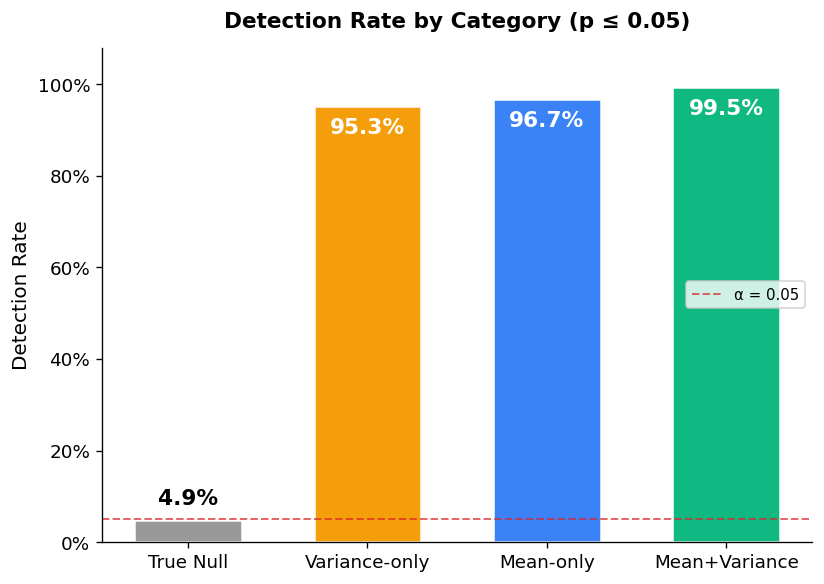

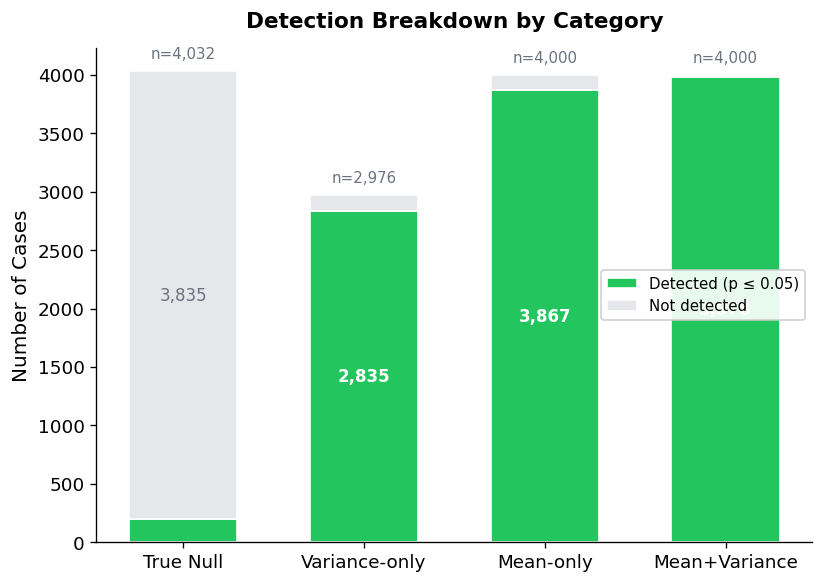

In [5]:
if not HAS_PERM_RESULTS:
    print('Skipped: requires permutation_all.parquet.')
else:
    det_rate = df.groupby('category').apply(
        lambda g: pd.Series({
            'n': int(len(g)),
            'detected': int(g['detected'].sum()),
            'not_detected': int((~g['detected']).sum()),
            'detection_rate': g['detected'].mean(),
        })
    ).loc[CAT_ORDER]
    display(det_rate)

    # --- Figure 1a: Detection Rate ---
    fig, ax = plt.subplots(figsize=(7, 5))
    x_pos = np.arange(len(CAT_ORDER))
    bars = ax.bar(x_pos, det_rate['detection_rate'],
                  width=0.6, color=[CAT_COLORS[c] for c in CAT_ORDER],
                  edgecolor='white', linewidth=1.5)

    for bar, rate, cat in zip(bars, det_rate['detection_rate'], CAT_ORDER):
        label = f'{rate:.1%}'
        y = bar.get_height()
        va = 'bottom' if y < 0.15 else 'top'
        offset = 0.025 if va == 'bottom' else -0.025
        color = 'black' if va == 'bottom' else 'white'
        ax.text(bar.get_x() + bar.get_width() / 2, y + offset, label,
                ha='center', va=va, fontsize=13, fontweight='bold', color=color)

    ax.set_xticks(x_pos)
    ax.set_xticklabels([CAT_LABELS[c] for c in CAT_ORDER], fontsize=11)
    ax.set_ylabel('Detection Rate', fontsize=12)
    ax.set_ylim(0, 1.08)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.axhline(ALPHA, color='#dc2626', ls='--', lw=1.2, alpha=0.7, label=f'α = {ALPHA}')
    ax.legend(fontsize=9, loc='center right')
    ax.set_title('Detection Rate by Category (p ≤ 0.05)', fontsize=13, fontweight='bold', pad=12)

    plt.tight_layout()
    fig.savefig(VIZ_DIR / 'fig1a_detection_rate.png', dpi=150, bbox_inches='tight')
    plt.show()

    # --- Figure 1b: Case Count Breakdown (vertical stacked bars) ---
    fig, ax = plt.subplots(figsize=(7, 5))
    x_pos = np.arange(len(CAT_ORDER))
    det_vals = det_rate['detected'].values.astype(float)
    not_det_vals = det_rate['not_detected'].values.astype(float)
    n_vals = det_rate['n'].values.astype(float)

    bars_det = ax.bar(x_pos, det_vals, width=0.6,
                      color='#22c55e', label='Detected (p ≤ 0.05)', edgecolor='white', linewidth=1)
    bars_nd = ax.bar(x_pos, not_det_vals, width=0.6, bottom=det_vals,
                     color='#e5e7eb', label='Not detected', edgecolor='white', linewidth=1)

    for i, (x, d, nd, n) in enumerate(zip(x_pos, det_vals, not_det_vals, n_vals)):
        if d > n * 0.08:
            ax.text(x, d / 2, f'{int(d):,}', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white')
        if nd > n * 0.08:
            ax.text(x, d + nd / 2, f'{int(nd):,}', ha='center', va='center',
                    fontsize=10, color='#6b7280')
        ax.text(x, n + 80, f'n={int(n):,}', ha='center', va='bottom',
                fontsize=9, color='#6b7280')

    ax.set_xticks(x_pos)
    ax.set_xticklabels([CAT_LABELS[c] for c in CAT_ORDER], fontsize=11)
    ax.set_ylabel('Number of Cases', fontsize=12)
    ax.legend(fontsize=9, loc='center right', framealpha=0.9)
    ax.set_title('Detection Breakdown by Category', fontsize=13, fontweight='bold', pad=12)

    plt.tight_layout()
    fig.savefig(VIZ_DIR / 'fig1b_detection_breakdown.png', dpi=150, bbox_inches='tight')
    plt.show()

## 2. p-Value Uniformity Under True Null

If the test is well-calibrated, True Null p-values should follow Uniform(0,1).
Deviation indicates either conservatism (p > expected) or anti-conservatism (p < expected).

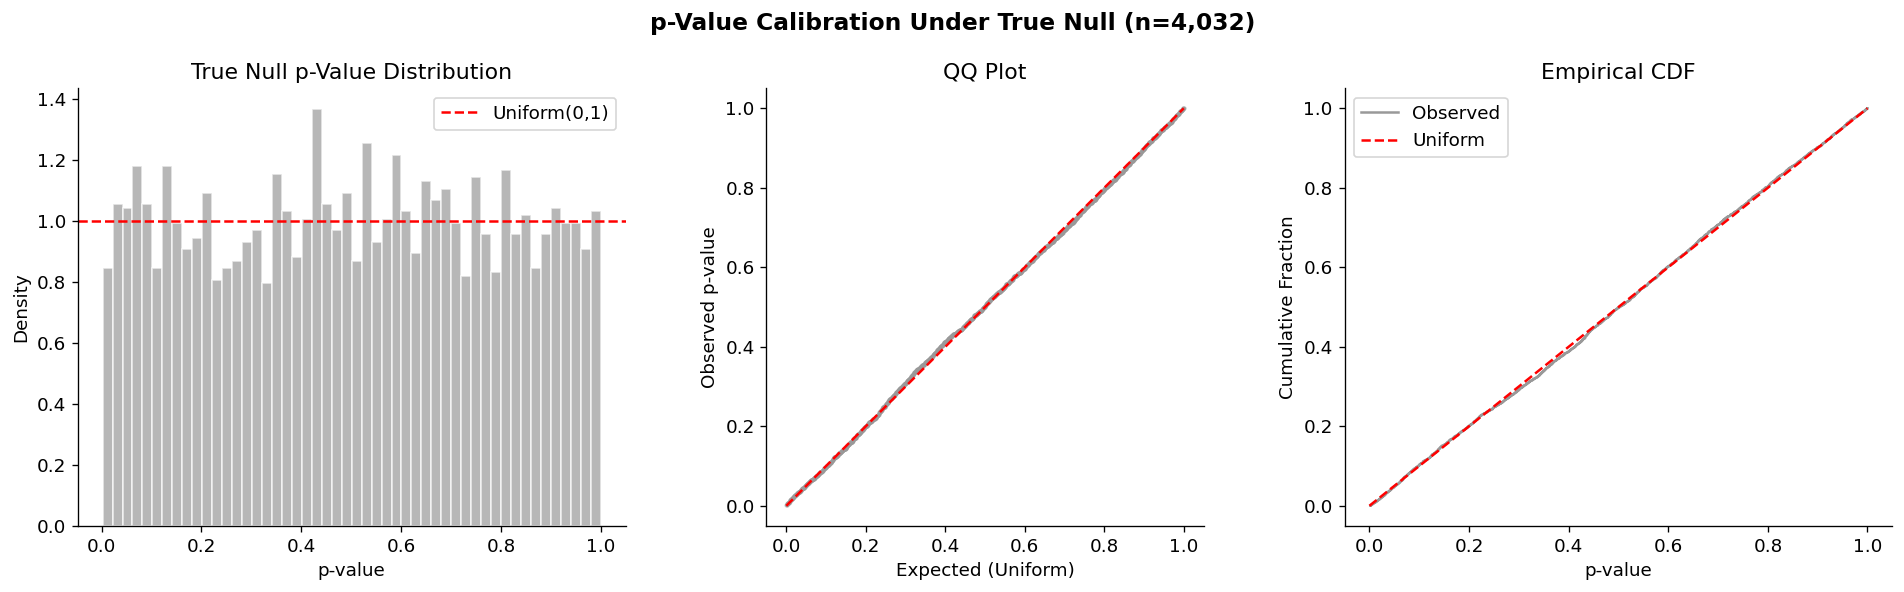

KS test vs Uniform(0,1): statistic=0.0147, p=0.3465
Empirical FPR at α=0.05: 0.0489
Empirical FPR at α=0.01: 0.0082


In [6]:
if not HAS_PERM_RESULTS:
    print('Skipped: requires permutation_all.parquet.')
else:
    tn = df[df['category'] == 'true_null'].copy()

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Histogram
    ax = axes[0]
    ax.hist(tn['p_value'], bins=50, density=True, color='#999999', alpha=0.7, edgecolor='white')
    ax.axhline(1.0, color='red', ls='--', lw=1.5, label='Uniform(0,1)')
    ax.set_xlabel('p-value')
    ax.set_ylabel('Density')
    ax.set_title('True Null p-Value Distribution')
    ax.legend()

    # QQ plot
    ax = axes[1]
    p_sorted = np.sort(tn['p_value'].values)
    n = len(p_sorted)
    expected = np.arange(1, n + 1) / (n + 1)
    ax.scatter(expected, p_sorted, s=2, alpha=0.3, color='#999999')
    ax.plot([0, 1], [0, 1], 'r--', lw=1.5)
    ax.set_xlabel('Expected (Uniform)')
    ax.set_ylabel('Observed p-value')
    ax.set_title('QQ Plot')
    ax.set_aspect('equal')

    # Empirical CDF
    ax = axes[2]
    ax.plot(p_sorted, np.arange(1, n + 1) / n, color='#999999', label='Observed')
    ax.plot([0, 1], [0, 1], 'r--', lw=1.5, label='Uniform')
    ax.set_xlabel('p-value')
    ax.set_ylabel('Cumulative Fraction')
    ax.set_title('Empirical CDF')
    ax.legend()

    plt.suptitle(f'p-Value Calibration Under True Null (n={len(tn):,})',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    fig.savefig(VIZ_DIR / 'fig2_pvalue_uniformity.png', dpi=150, bbox_inches='tight')
    plt.show()

    ks_stat, ks_p = stats.kstest(tn['p_value'], 'uniform')
    print(f'KS test vs Uniform(0,1): statistic={ks_stat:.4f}, p={ks_p:.4g}')
    print(f'Empirical FPR at α=0.05: {(tn["p_value"] <= 0.05).mean():.4f}')
    print(f'Empirical FPR at α=0.01: {(tn["p_value"] <= 0.01).mean():.4f}')

## 3. FPR Calibration

False positive rate at various α levels. Also broken down by spread pattern and x-distribution.

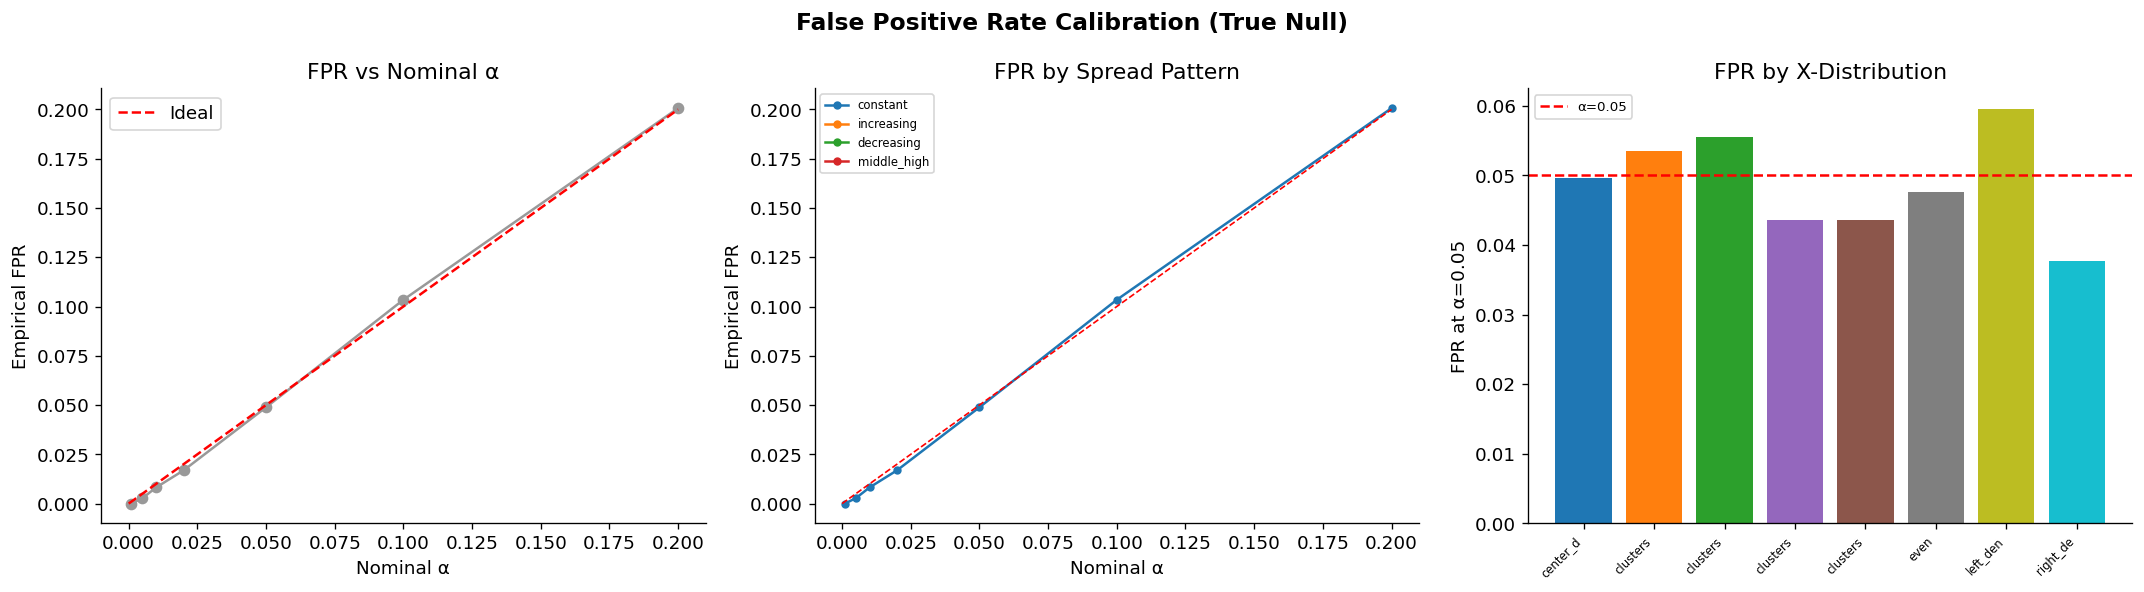

In [7]:
if not HAS_PERM_RESULTS:
    print('Skipped: requires permutation_all.parquet.')
else:
    alphas = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10, 0.20]
    fpr_overall = [float((tn['p_value'] <= a).mean()) for a in alphas]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Overall FPR vs α
    ax = axes[0]
    ax.plot(alphas, fpr_overall, 'o-', color='#999999', markersize=6)
    ax.plot([0, 0.2], [0, 0.2], 'r--', lw=1.5, label='Ideal')
    ax.set_xlabel('Nominal α')
    ax.set_ylabel('Empirical FPR')
    ax.set_title('FPR vs Nominal α')
    ax.legend()

    # FPR by spread pattern
    ax = axes[1]
    for sp in ['constant', 'increasing', 'decreasing', 'middle_high']:
        sub = tn[tn['spread_pattern'] == sp]
        fpr_sp = [float((sub['p_value'] <= a).mean()) for a in alphas]
        ax.plot(alphas, fpr_sp, 'o-', markersize=4, label=sp)
    ax.plot([0, 0.2], [0, 0.2], 'r--', lw=1)
    ax.set_xlabel('Nominal α')
    ax.set_ylabel('Empirical FPR')
    ax.set_title('FPR by Spread Pattern')
    ax.legend(fontsize=7)

    # FPR by x-distribution
    ax = axes[2]
    x_dists = tn['x_distribution'].unique()
    fpr_by_xdist = {}
    for xd in sorted(x_dists):
        sub = tn[tn['x_distribution'] == xd]
        fpr_by_xdist[xd] = float((sub['p_value'] <= 0.05).mean())
    colors = plt.cm.tab10(np.linspace(0, 1, len(fpr_by_xdist)))
    bars = ax.bar(range(len(fpr_by_xdist)), list(fpr_by_xdist.values()), color=colors)
    ax.axhline(0.05, color='red', ls='--', lw=1.5, label='α=0.05')
    ax.set_xticks(range(len(fpr_by_xdist)))
    ax.set_xticklabels([xd[:8] for xd in fpr_by_xdist.keys()], rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('FPR at α=0.05')
    ax.set_title('FPR by X-Distribution')
    ax.legend(fontsize=8)

    plt.suptitle('False Positive Rate Calibration (True Null)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    fig.savefig(VIZ_DIR / 'fig3_fpr_calibration.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5. Detection Power by SNR

For mean-only and mean+variance cases, detection rate as a function of SNR.

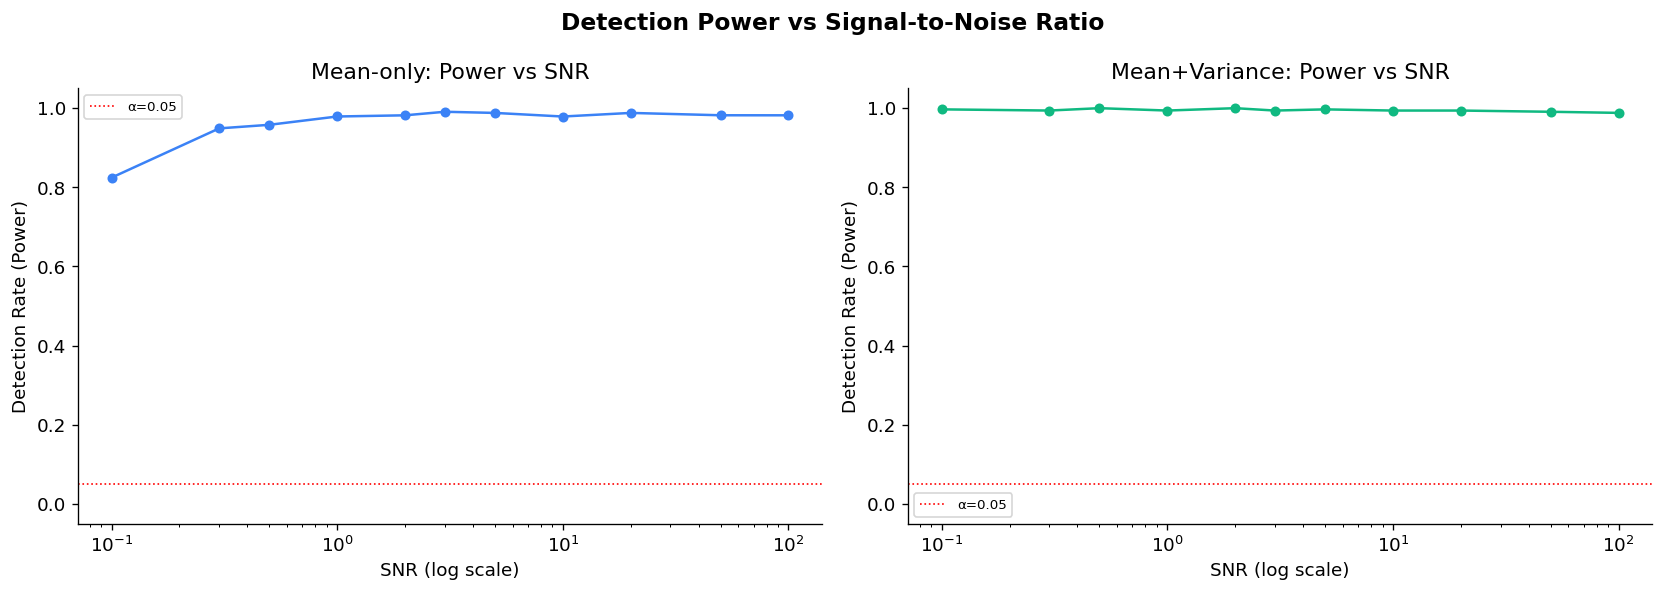

In [8]:
if not HAS_PERM_RESULTS:
    print('Skipped: requires permutation_all.parquet.')
else:
    signal = df[df['category'].isin(['mean_only', 'mean+variance'])].copy()
    signal['snr_num'] = pd.to_numeric(signal['snr'], errors='coerce')
    signal = signal[signal['snr_num'].notna() & np.isfinite(signal['snr_num'])]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, cat, color in zip(axes, ['mean_only', 'mean+variance'],
                               [CAT_COLORS['mean_only'], CAT_COLORS['mean+variance']]):
        sub = signal[signal['category'] == cat]
        det_by_snr = sub.groupby('snr_num')['detected'].mean().reset_index(name='detection_rate')

        ax.plot(det_by_snr['snr_num'], det_by_snr['detection_rate'],
                'o-', color=color, markersize=5)
        ax.axhline(ALPHA, color='red', ls=':', lw=1, label=f'α={ALPHA}')
        ax.set_xscale('log')
        ax.set_xlabel('SNR (log scale)')
        ax.set_ylabel('Detection Rate (Power)')
        ax.set_title(f'{CAT_LABELS[cat]}: Power vs SNR')
        ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=8)

    plt.suptitle('Detection Power vs Signal-to-Noise Ratio', fontsize=14, fontweight='bold')
    plt.tight_layout()
    fig.savefig(VIZ_DIR / 'fig5_detection_by_snr.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Detection by Function Family

Per-family detection rate (mean-only, collapsed across SNR).

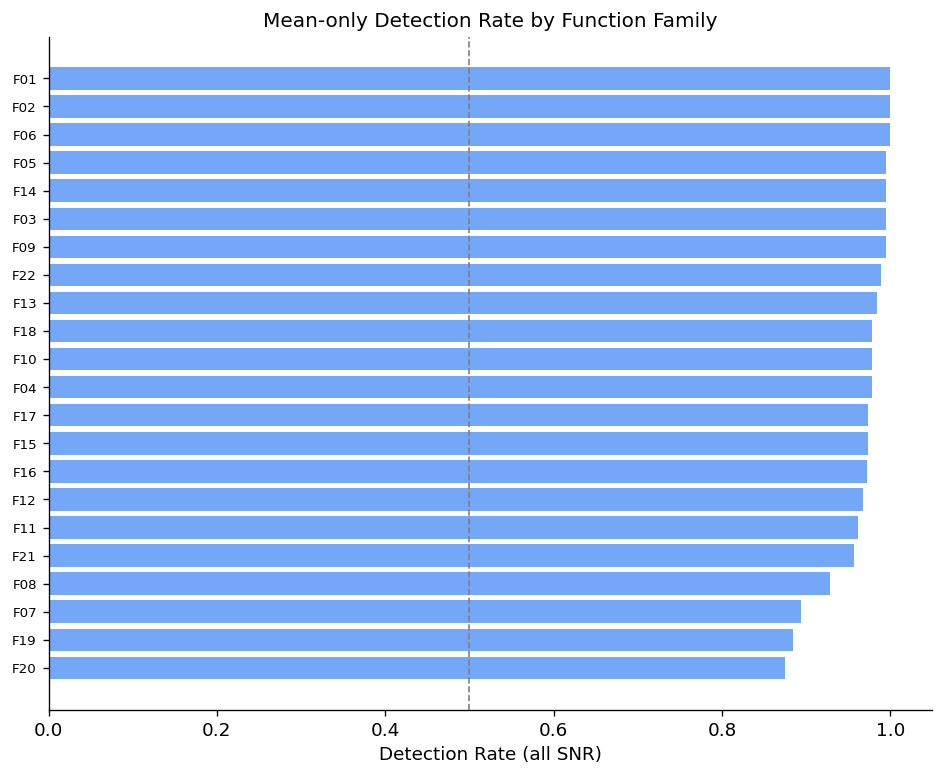

In [9]:
if not HAS_PERM_RESULTS:
    print('Skipped: requires permutation_all.parquet.')
else:
    mo = df[df['category'] == 'mean_only']
    det_by_fam = mo.groupby('family_id')['detected'].mean().sort_values(ascending=True).rename('detection_rate')

    fig, ax = plt.subplots(figsize=(8, max(5, len(det_by_fam) * 0.3)))
    colors = ['#3b82f6' if r > 0.5 else '#ef4444' for r in det_by_fam.values]
    ax.barh(range(len(det_by_fam)), det_by_fam.values, color=colors, alpha=0.7)
    ax.set_yticks(range(len(det_by_fam)))
    ax.set_yticklabels(det_by_fam.index, fontsize=8)
    ax.set_xlabel('Detection Rate (all SNR)')
    ax.set_title('Mean-only Detection Rate by Function Family', fontsize=12)
    ax.axvline(0.5, color='gray', ls='--', lw=1)
    plt.tight_layout()
    fig.savefig(VIZ_DIR / 'fig6_detection_by_family.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. Metric Contribution to Joint Test

For detected cases: which metric had the highest Z-score (drove the joint T)?

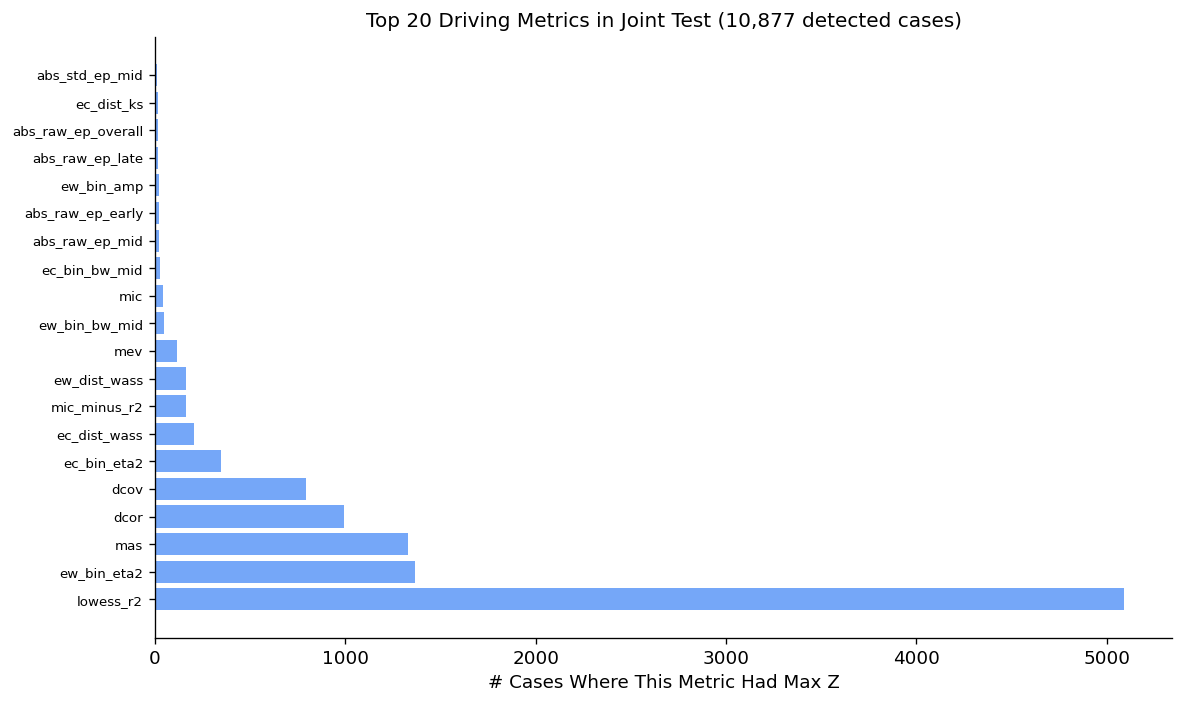


Mean-only — top drivers:
  lowess_r2                           2,655 (68.7%)
  ew_bin_eta2                           702 (18.2%)
  ec_bin_eta2                           160 (4.1%)
  dcor                                  126 (3.3%)
  dcov                                   99 (2.6%)

Mean+Variance — top drivers:
  lowess_r2                           2,421 (60.9%)
  ew_bin_eta2                           654 (16.4%)
  dcor                                  317 (8.0%)
  dcov                                  266 (6.7%)
  ec_bin_eta2                           176 (4.4%)

Variance-only — top drivers:
  mas                                 1,232 (43.5%)
  dcor                                  543 (19.2%)
  dcov                                  425 (15.0%)
  mic_minus_r2                          163 (5.7%)
  ec_dist_wass                          126 (4.4%)


In [10]:
if not HAS_PERM_RESULTS:
    print('Skipped: requires permutation_all.parquet.')
else:
    detected = df[df['detected']].copy()

    if len(Z_COLS) > 0 and len(detected) > 0:
        z_matrix = detected[Z_COLS].values
        max_idx = np.argmax(z_matrix, axis=1)
        detected['driving_metric'] = [Z_COLS[i].replace('z_', '') for i in max_idx]

        driver_counts = detected['driving_metric'].value_counts().head(20)

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.barh(range(len(driver_counts)), driver_counts.values, color='#3b82f6', alpha=0.7)
        ax.set_yticks(range(len(driver_counts)))
        ax.set_yticklabels(driver_counts.index, fontsize=8)
        ax.set_xlabel('# Cases Where This Metric Had Max Z')
        ax.set_title(f'Top 20 Driving Metrics in Joint Test ({len(detected):,} detected cases)',
                     fontsize=12)
        plt.tight_layout()
        fig.savefig(VIZ_DIR / 'fig7_driving_metrics.png', dpi=150, bbox_inches='tight')
        plt.show()

        for cat in ['mean_only', 'mean+variance', 'variance_only']:
            sub = detected[detected['category'] == cat]
            if len(sub) > 0:
                top5 = sub['driving_metric'].value_counts().head(5)
                print(f'\n{CAT_LABELS[cat]} — top drivers:')
                for m, c in top5.items():
                    print(f'  {m:35s} {c:>5,} ({c/len(sub):.1%})')
    else:
        print('No z-score columns or no detected cases found')

## 8. Variance-Only Detection

Detection rates for variance-only cases, broken down by spread pattern and x-distribution.

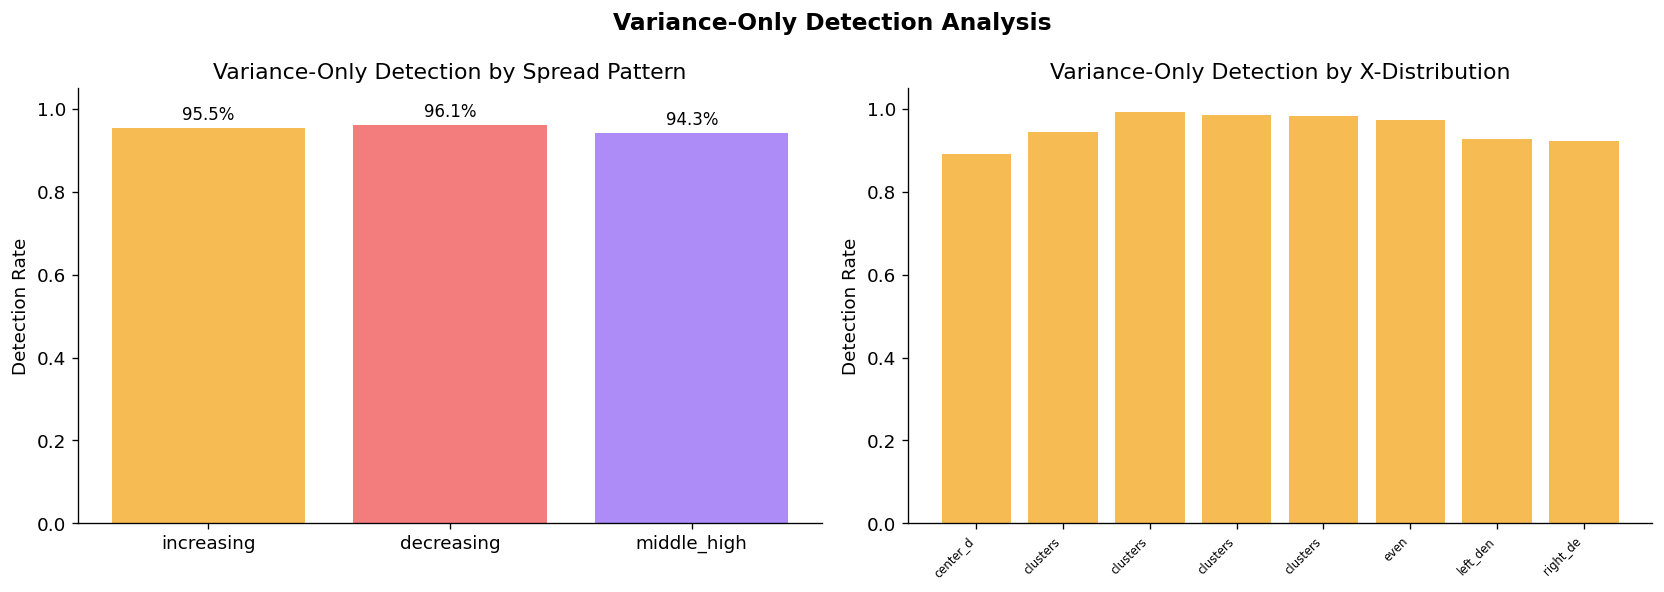

Overall variance-only detection rate: 95.3%


In [11]:
if not HAS_PERM_RESULTS:
    print('Skipped: requires permutation_all.parquet.')
else:
    vo = df[df['category'] == 'variance_only']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # By spread pattern
    ax = axes[0]
    spread_patterns = ['increasing', 'decreasing', 'middle_high']
    det_by_sp = []
    for sp in spread_patterns:
        sub = vo[vo['spread_pattern'] == sp]
        det_by_sp.append(float(sub['detected'].mean()))
    bars = ax.bar(spread_patterns, det_by_sp,
                  color=['#f59e0b', '#ef4444', '#8b5cf6'], alpha=0.7)
    for bar, rate in zip(bars, det_by_sp):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{rate:.1%}', ha='center', fontsize=10)
    ax.set_ylabel('Detection Rate')
    ax.set_title('Variance-Only Detection by Spread Pattern')
    ax.set_ylim(0, 1.05)

    # By x-distribution
    ax = axes[1]
    x_dists = sorted(vo['x_distribution'].unique())
    det_by_xd = []
    for xd in x_dists:
        sub = vo[vo['x_distribution'] == xd]
        det_by_xd.append(float(sub['detected'].mean()))
    ax.bar(range(len(x_dists)), det_by_xd, color='#f59e0b', alpha=0.7)
    ax.set_xticks(range(len(x_dists)))
    ax.set_xticklabels([xd[:8] for xd in x_dists], rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('Detection Rate')
    ax.set_title('Variance-Only Detection by X-Distribution')
    ax.set_ylim(0, 1.05)

    plt.suptitle('Variance-Only Detection Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    fig.savefig(VIZ_DIR / 'fig8_variance_only_detection.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Overall variance-only detection rate: {vo["detected"].mean():.1%}')

## 9. Metric Group Ablation

Compare joint-test detection when different metric groups are removed.
Uses the individual metric Z-scores to simulate ablation without re-running permutation.

In [12]:
if not HAS_PERM_RESULTS:
    print('Skipped: requires permutation_all.parquet.')
else:
    metric_groups = {
        'Correlation': [c for c in Z_COLS if any(k in c for k in ['pearson', 'spearman', 'covariance'])],
        'Distance': [c for c in Z_COLS if any(k in c for k in ['dcov', 'dcor'])],
        'Slopes': [c for c in Z_COLS if any(k in c for k in ['_ep_', '_pf_', 'seg_strength'])],
        'Bin-based': [c for c in Z_COLS if any(k in c for k in ['bin_eta', 'bin_amp', 'bin_bw'])],
        'Distribution': [c for c in Z_COLS if any(k in c for k in ['dist_ks', 'dist_wass'])],
        'MINE': [c for c in Z_COLS if any(k in c for k in ['mic', 'mas', 'mev', 'mcn'])],
        'LOWESS': [c for c in Z_COLS if 'lowess' in c],
    }

    signal_cases = df[df['category'].isin(['mean_only', 'mean+variance'])].copy()
    z_matrix_full = signal_cases[Z_COLS].fillna(0).values

    full_max_z = z_matrix_full.max(axis=1)
    full_det_rate = float(signal_cases['detected'].mean())

    ablation_results = [{'group': 'All metrics', 'detection_rate': full_det_rate, 'n_metrics': len(Z_COLS)}]

    for group_name, group_cols in metric_groups.items():
        remaining = [c for c in Z_COLS if c not in group_cols]
        if len(remaining) == 0:
            continue
        remaining_max_z = signal_cases[remaining].fillna(0).values.max(axis=1)
        ablation_results.append({
            'group': f'Without {group_name}',
            'detection_rate': np.nan,
            'n_metrics': len(remaining),
            'removed': len(group_cols),
            'mean_max_z_drop': float((full_max_z - remaining_max_z).mean()),
        })

    abl_df = pd.DataFrame(ablation_results)
    display(abl_df)

    print('\n=== Max-Z Contribution by Metric Group ===')
    z_matrix_df = signal_cases[Z_COLS].fillna(0)
    max_col = z_matrix_df.idxmax(axis=1)
    for group_name, group_cols in metric_groups.items():
        frac = max_col.isin(group_cols).mean()
        print(f'  {group_name:15s}: {frac:.1%} of cases have max-Z from this group')

,group,detection_rate,n_metrics,removed,mean_max_z_drop
0,All metrics,0.980625,45,NaN,NaN
1,Without Correlation,NaN,42,3.0,3.196459e-06
2,Without Distance,NaN,43,2.0,1.756676e-01
3,Without Slopes,NaN,27,18.0,4.796636e-01
4,Without Bin-based,NaN,33,12.0,2.738366e+00
5,Without Distribution,NaN,41,4.0,9.085045e-03
6,Without MINE,NaN,40,5.0,6.479907e-02
7,Without LOWESS,NaN,44,1.0,5.141971e+07



=== Max-Z Contribution by Metric Group ===
  Correlation    : 0.0% of cases have max-Z from this group
  Distance       : 10.2% of cases have max-Z from this group
  Slopes         : 0.8% of cases have max-Z from this group
  Bin-based      : 22.3% of cases have max-Z from this group
  Distribution   : 1.9% of cases have max-Z from this group
  MINE           : 1.2% of cases have max-Z from this group
  LOWESS         : 63.6% of cases have max-Z from this group


## Summary

In [13]:
if not HAS_PERM_RESULTS:
    print('Skipped: requires permutation_all.parquet.')
else:
    print('=' * 60)
    print('PERMUTATION TEST SUMMARY')
    print('=' * 60)
    print(f'Total cases: {len(df):,}')
    print(f'Z-score metrics in joint test: {len(Z_COLS)}')
    print(f'Detection rule: p = #{{T_perm >= T_obs}} / B;  p <= {ALPHA} -> detectable')
    print()

    for cat in CAT_ORDER:
        sub = df[df['category'] == cat]
        det = sub['detected'].mean()
        print(f'{CAT_LABELS[cat]:18s}: {len(sub):>7,} cases, detection rate = {det:.1%}')

    print()
    tn = df[df['category'] == 'true_null']
    print(f'True Null FPR (α=0.05): {(tn["p_value"] <= 0.05).mean():.4f}')
    print(f'True Null FPR (α=0.01): {(tn["p_value"] <= 0.01).mean():.4f}')

PERMUTATION TEST SUMMARY
Total cases: 15,008
Z-score metrics in joint test: 45
Detection rule: p = #{T_perm >= T_obs} / B;  p <= 0.05 -> detectable

True Null         :   4,032 cases, detection rate = 4.9%
Variance-only     :   2,976 cases, detection rate = 95.3%
Mean-only         :   4,000 cases, detection rate = 96.7%
Mean+Variance     :   4,000 cases, detection rate = 99.5%

True Null FPR (α=0.05): 0.0489
True Null FPR (α=0.01): 0.0082
